# 4.2 - HCP background-dependence summary analyses for EC

This notebook continues the HCP background-dependence workflow using the dataframe generated.

This notebook focuses on the following analysis:

1. Subject-wise correlation between baseline energy and average perturbation magnitude
2. Subject-wise correlation between baseline energy and average evoked energy
3. Example scatter plots for selected subjects
4. Node-wise local vs global energy–effect correlations across subjects

## Expected input

- `HCP_4_df_background_dependence.pkl`
- `HCP_4_df_background_dependence.csv`


In [1]:
from pathlib import Path
import sys
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# -----------------------------------------------------------------------------
# Path and environment configuration
# -----------------------------------------------------------------------------
repo_dir = Path.cwd().resolve().parent
data_dir = repo_dir / "Results"

df_pkl_path = data_dir / "HCP_4_df_background_dependence.pkl"
df_csv_path = data_dir / "HCP_4_df_background_dependence.csv"

print("Repository directory :", repo_dir)
print("Results directory    :", data_dir)
print("PKL path             :", df_pkl_path)
print("CSV path             :", df_csv_path)


Repository directory : C:\Users\tomas\Documents\PhD\Projects\BrainStim
Results directory    : C:\Users\tomas\Documents\PhD\Projects\BrainStim\Results
PKL path             : C:\Users\tomas\Documents\PhD\Projects\BrainStim\Results\HCP_4_df_background_dependence.pkl
CSV path             : C:\Users\tomas\Documents\PhD\Projects\BrainStim\Results\HCP_4_df_background_dependence.csv


In [2]:
# =============================================================================
# Plotting helper
# =============================================================================
def nice_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(ls="--", alpha=0.25)
    return ax

def safe_pearsonr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if len(x) < 3:
        return np.nan, np.nan
    if np.allclose(np.std(x), 0) or np.allclose(np.std(y), 0):
        return np.nan, np.nan
    return pearsonr(x, y)

print("Helpers loaded.")


Helpers loaded.


In [3]:
# =============================================================================
# Load background-dependence dataframe
# =============================================================================
if df_pkl_path.exists():
    df_bd = pd.read_pickle(df_pkl_path)
    print(f"Loaded dataframe from PKL: {df_pkl_path}")
elif df_csv_path.exists():
    df_bd = pd.read_csv(df_csv_path)
    print(f"Loaded dataframe from CSV: {df_csv_path}")
else:
    raise FileNotFoundError(
        "Could not find HCP_4_df_background_dependence.pkl or .csv in Results/. "
        "Run HCP_4.2_Background_dependence_dataframe first."
    )

expected_cols = [
    "sub_id",
    "roi",
    "time",
    "global_baseline_energy",
    "global_evoked_energy",
    "global_effect_size",
    "global_effect_direction",
    "local_baseline_energy",
    "local_evoked_energy",
    "local_effect_size",
    "local_effect_direction",
]

missing_cols = [c for c in expected_cols if c not in df_bd.columns]
if missing_cols:
    raise ValueError(f"Missing expected columns: {missing_cols}")

df_bd = df_bd.copy()
df_bd["sub_id"] = df_bd["sub_id"].astype(str)
df_bd["roi"] = pd.to_numeric(df_bd["roi"], errors="coerce").astype(int)
df_bd["time"] = pd.to_numeric(df_bd["time"], errors="coerce").astype(int)

print("Dataframe shape:", df_bd.shape)
display(df_bd.head())


Loaded dataframe from PKL: C:\Users\tomas\Documents\PhD\Projects\BrainStim\Results\HCP_4_df_background_dependence.pkl
Dataframe shape: (22500000, 11)


,sub_id,roi,time,global_baseline_energy,global_evoked_energy,global_effect_size,global_effect_direction,local_baseline_energy,local_evoked_energy,local_effect_size,local_effect_direction
0,id_100206,0,0,231.013324,297.870885,0.000613,0.087655,0.101116,0.108318,0.000220,0.014824
1,id_100206,1,0,231.013324,297.758308,0.000505,0.088632,0.132412,0.165010,0.000143,0.011976
2,id_100206,2,0,231.013324,297.848720,0.000869,0.045001,0.008565,0.004545,0.000435,0.020855
3,id_100206,3,0,231.013324,297.872094,0.001219,0.079357,1.187434,0.829594,0.000665,0.025785
4,id_100206,4,0,231.013324,297.788434,0.001340,0.036414,0.105217,0.352798,0.000815,0.028555


## Subject-wise global analyses

The first analyses reproduce the subject-level correlations that were computed directly from `EC_t` and the model outputs in the earlier notebooks, now using the consolidated dataframe from notebook 4.2.


In [4]:
# =============================================================================
# Subject-wise correlation: baseline energy vs average effect size
# =============================================================================
subject_global = (
    df_bd.groupby(["sub_id", "time"], as_index=False)
         .agg(
             global_baseline_energy=("global_baseline_energy", "first"),
             global_effect_size_mean=("global_effect_size", "mean"),
             global_evoked_energy_mean=("global_evoked_energy", "mean"),
         )
)

results_global = []
scatter_data_global = {}

for sid, sub_df in subject_global.groupby("sub_id"):
    x = sub_df["global_baseline_energy"].to_numpy()
    y = sub_df["global_effect_size_mean"].to_numpy()
    r, p = safe_pearsonr(x, y)
    results_global.append({"sub_id": sid, "r": r, "p": p, "n_timepoints": len(sub_df)})
    scatter_data_global[sid] = (x, y)

df_corr_global = pd.DataFrame(results_global).sort_values("sub_id").reset_index(drop=True)
display(df_corr_global.head())
print("Average correlation across subjects:", df_corr_global["r"].mean())

,sub_id,r,p,n_timepoints
0,id_100206,-0.548763,1.161019e-40,500
1,id_100307,-0.575257,2.164544e-45,500
2,id_100408,-0.593244,7.426676e-49,500
3,id_101006,-0.676053,4.761371e-68,500
4,id_101107,-0.663606,9.054280e-65,500


Average correlation across subjects: -0.5482411277242668


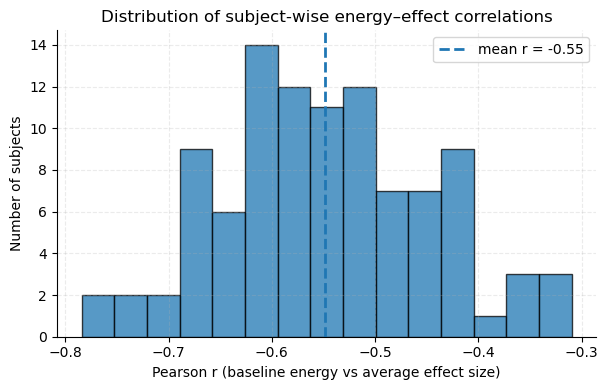

In [5]:
# =============================================================================
# Histogram of subject-wise global energy–effect correlations
# =============================================================================
plt.figure(figsize=(6.2, 4.0))
plt.hist(df_corr_global["r"].dropna(), bins=15, edgecolor="k", alpha=0.75)
plt.axvline(df_corr_global["r"].mean(), linestyle="--", linewidth=2,
            label=f"mean r = {df_corr_global['r'].mean():.2f}")
plt.xlabel("Pearson r (baseline energy vs average effect size)")
plt.ylabel("Number of subjects")
plt.title("Distribution of subject-wise energy–effect correlations")
plt.legend()
nice_axes(plt.gca())
plt.tight_layout()
plt.show()


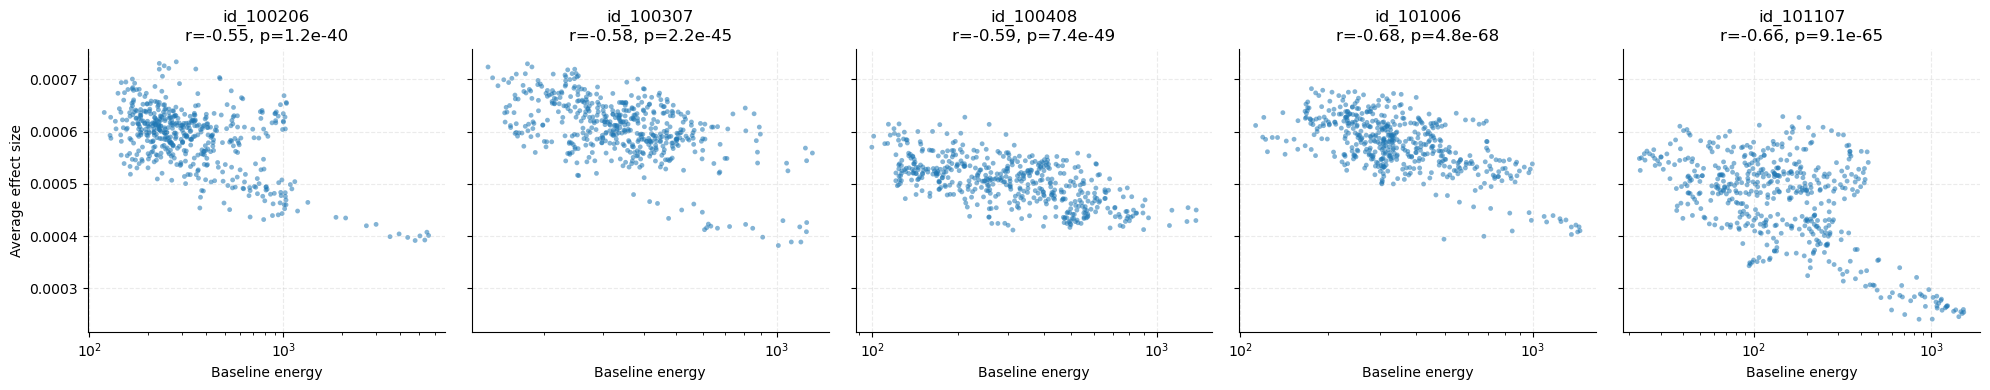

In [6]:
# =============================================================================
# Scatter plots for selected subjects
# =============================================================================
n_plot = min(5, len(scatter_data_global))
sel_subjects = list(scatter_data_global.keys())[:n_plot]

fig, axs = plt.subplots(1, n_plot, figsize=(4*n_plot, 4), sharey=True)
if n_plot == 1:
    axs = [axs]

for ax, sid in zip(axs, sel_subjects):
    x, y = scatter_data_global[sid]
    row = df_corr_global.loc[df_corr_global["sub_id"] == sid].iloc[0]
    ax.scatter(x, y, s=12, alpha=0.55, edgecolors="none")
    ax.set_title(f"{sid}\nr={row['r']:.2f}, p={row['p']:.2g}")
    ax.set_xlabel("Baseline energy")
    if ax == axs[0]:
        ax.set_ylabel("Average effect size")
    if np.all(x > 0):
        ax.set_xscale("log")
    nice_axes(ax)

plt.tight_layout()
plt.show()


In [7]:
# =============================================================================
# Subject-wise correlation: baseline energy vs average evoked energy
# =============================================================================
results_poststim = []
scatter_data_poststim = {}

for sid, sub_df in subject_global.groupby("sub_id"):
    x = sub_df["global_baseline_energy"].to_numpy()
    y = sub_df["global_evoked_energy_mean"].to_numpy()
    r, p = safe_pearsonr(x, y)
    results_poststim.append({"sub_id": sid, "r": r, "p": p, "n_timepoints": len(sub_df)})
    scatter_data_poststim[sid] = (x, y)

df_corr_poststim = pd.DataFrame(results_poststim).sort_values("sub_id").reset_index(drop=True)
display(df_corr_poststim.head())
print("Average correlation across subjects:", df_corr_poststim["r"].mean())

,sub_id,r,p,n_timepoints
0,id_100206,0.972244,2.549123e-316,500
1,id_100307,0.973082,1.365400e-319,500
2,id_100408,0.978425,0.000000e+00,500
3,id_101006,0.990020,0.000000e+00,500
4,id_101107,0.984921,0.000000e+00,500


Average correlation across subjects: 0.9791872184330029


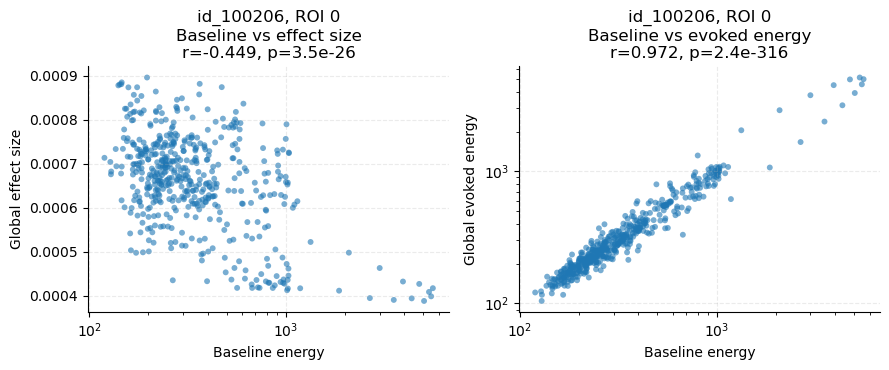

In [8]:
# =============================================================================
# Example scatter plots for one subject and one region
# =============================================================================
subject_ids = sorted(df_bd["sub_id"].unique())
sid = subject_ids[0]
roi = int(df_bd.loc[df_bd["sub_id"] == sid, "roi"].min())

df_ex = df_bd[(df_bd["sub_id"] == sid) & (df_bd["roi"] == roi)].sort_values("time")

x = df_ex["global_baseline_energy"].to_numpy()
y_effect = df_ex["global_effect_size"].to_numpy()
y_evoked = df_ex["global_evoked_energy"].to_numpy()

r1, p1 = safe_pearsonr(x, y_effect)
r2, p2 = safe_pearsonr(x, y_evoked)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.0, 3.8))

ax1.scatter(x, y_effect, s=18, alpha=0.6, edgecolors="none")
ax1.set_xlabel("Baseline energy")
ax1.set_ylabel("Global effect size")
ax1.set_title(f"{sid}, ROI {roi}\nBaseline vs effect size\nr={r1:.3f}, p={p1:.2g}")
if np.all(x > 0):
    ax1.set_xscale("log")
nice_axes(ax1)

ax2.scatter(x, y_evoked, s=18, alpha=0.6, edgecolors="none")
ax2.set_xlabel("Baseline energy")
ax2.set_ylabel("Global evoked energy")
ax2.set_title(f"{sid}, ROI {roi}\nBaseline vs evoked energy\nr={r2:.3f}, p={p2:.2g}")
if np.all(x > 0):
    ax2.set_xscale("log")
if np.all(y_evoked > 0):
    ax2.set_yscale("log")
nice_axes(ax2)

plt.tight_layout()
plt.show()


## Node-wise local vs global correlations


In [9]:
# =============================================================================
# Compute node-wise local vs global energy–effect correlations
# =============================================================================
subject_ids = sorted(df_bd["sub_id"].unique())
roi_ids = np.sort(df_bd["roi"].unique())

rows = []

for sid in subject_ids:
    sub_df = df_bd[df_bd["sub_id"] == sid]

    for roi in roi_ids:
        node_df = sub_df[sub_df["roi"] == roi].sort_values("time")
        if node_df.empty:
            continue

        r_local, p_local = safe_pearsonr(
            node_df["local_baseline_energy"].to_numpy(),
            node_df["local_effect_size"].to_numpy(),
        )

        r_global, p_global = safe_pearsonr(
            node_df["global_baseline_energy"].to_numpy(),
            node_df["global_effect_size"].to_numpy(),
        )

        rows.append({
            "sub_id": sid,
            "roi": int(roi),
            "r_local": r_local,
            "p_local": p_local,
            "r_global": r_global,
            "p_global": p_global,
            "n_timepoints": len(node_df),
        })

df_node_corr = pd.DataFrame(rows).sort_values(["sub_id", "roi"]).reset_index(drop=True)
display(df_node_corr.head())
print("Node-wise correlation table shape:", df_node_corr.shape)

,sub_id,roi,r_local,p_local,r_global,p_global,n_timepoints
0,id_100206,0,-0.385313,3.825473e-19,-0.449095,3.456560e-26,500
1,id_100206,1,-0.366916,2.222010e-17,-0.486173,5.038398e-31,500
2,id_100206,2,-0.164154,2.274143e-04,-0.459122,1.943199e-27,500
3,id_100206,3,-0.325437,8.464777e-14,-0.418844,1.168769e-22,500
4,id_100206,4,-0.374088,4.702908e-18,-0.424514,2.710628e-23,500


Node-wise correlation table shape: (45000, 7)


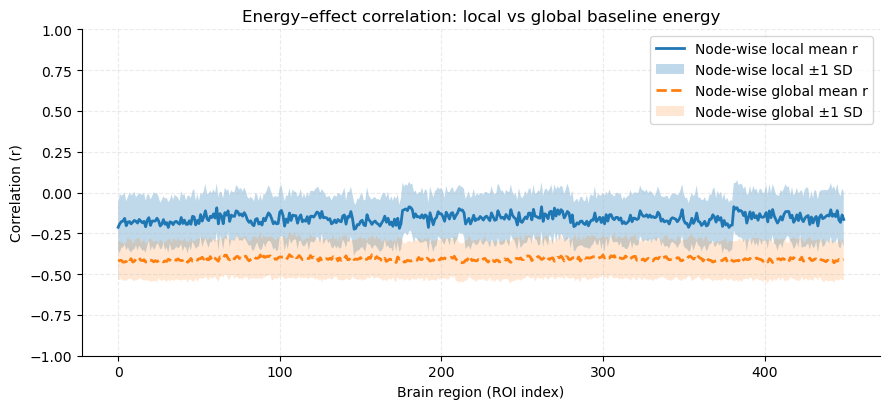

In [10]:
# =============================================================================
# Plot node-wise local vs global profiles (mean ± SD across subjects)
# =============================================================================
local_pivot = df_node_corr.pivot(index="sub_id", columns="roi", values="r_local").sort_index(axis=1)
global_pivot = df_node_corr.pivot(index="sub_id", columns="roi", values="r_global").sort_index(axis=1)

mean_r_local = local_pivot.mean(axis=0).to_numpy()
std_r_local = local_pivot.std(axis=0, ddof=1).to_numpy()

mean_r_global = global_pivot.mean(axis=0).to_numpy()
std_r_global = global_pivot.std(axis=0, ddof=1).to_numpy()

nodes = local_pivot.columns.to_numpy()

plt.figure(figsize=(9.0, 4.2))

plt.plot(nodes, mean_r_local, linewidth=2, label="Node-wise local mean r")
plt.fill_between(
    nodes,
    mean_r_local - std_r_local,
    mean_r_local + std_r_local,
    alpha=0.28,
    label="Node-wise local ±1 SD",
)

plt.plot(nodes, mean_r_global, linestyle="--", linewidth=2, label="Node-wise global mean r")
plt.fill_between(
    nodes,
    mean_r_global - std_r_global,
    mean_r_global + std_r_global,
    alpha=0.18,
    label="Node-wise global ±1 SD",
)

plt.xlabel("Brain region (ROI index)")
plt.ylabel("Correlation (r)")
plt.title("Energy–effect correlation: local vs global baseline energy")
plt.ylim(-1, 1)
plt.legend()
nice_axes(plt.gca())
plt.tight_layout()
plt.show()


In [11]:
# =============================================================================
# Optional summary tables
# =============================================================================
summary_local_global = pd.DataFrame({
    "roi": local_pivot.columns.to_numpy(),
    "mean_r_local": mean_r_local,
    "std_r_local": std_r_local,
    "mean_r_global": mean_r_global,
    "std_r_global": std_r_global,
}).sort_values("roi").reset_index(drop=True)

display(summary_local_global.head())
#summary_local_global.to_csv(summary_dir / "HCP_4.3_nodewise_local_global_summary.csv", index=False)
#print("Saved:", summary_dir / "HCP_4.3_nodewise_local_global_summary.csv")


,roi,mean_r_local,std_r_local,mean_r_global,std_r_global
0,0,-0.212962,0.146164,-0.420395,0.114174
1,1,-0.190469,0.179717,-0.416361,0.119565
2,2,-0.178284,0.159269,-0.415508,0.109921
3,3,-0.174876,0.162010,-0.426376,0.114984
4,4,-0.158482,0.158501,-0.425683,0.110789
